<a href="https://colab.research.google.com/github/nishant4500/End-to-End-ETL-ML-Pipeline-/blob/main/Walmart_sales_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import joblib

In [ ]:
data = pd.read_csv('train.csv')
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

In [ ]:
features["CPI"].fillna(features["CPI"].median(), inplace=True)
features["Unemployment"].fillna(features["Unemployment"].median(), inplace=True)

for i in range(1,6):
    features["MarkDown"+str(i)] = features["MarkDown"+str(i)].apply(lambda x: 0 if x < 0 else x)
    features["MarkDown"+str(i)].fillna(0, inplace=True)

/tmp/ipykernel_1426/3190431626.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  features["CPI"].fillna(features["CPI"].median(), inplace=True)
/tmp/ipykernel_1426/3190431626.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [ ]:
data = data.merge(stores, on='Store')
data = data.merge(features, on=['Store','Date'])

In [ ]:
data['Date'] = pd.to_datetime(data['Date'])
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Week'] = data['Date'].dt.isocalendar().week

In [ ]:
agg = data.groupby(['Store','Dept']).Weekly_Sales.agg(['max','min','mean','median','std']).reset_index()
data = data.merge(agg, on=['Store','Dept'])

In [ ]:
data['Total_MarkDown'] = data[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].sum(axis=1)
data.drop(['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5'], axis=1, inplace=True)

In [ ]:
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,CPI,...,IsHoliday_y,Year,Month,Week,max,min,mean,median,std,Total_MarkDown
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,211.096358,...,False,2010,2,5,57592.12,14537.37,22513.322937,18535.48,9854.349032,0.0
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,211.242170,...,True,2010,2,6,57592.12,14537.37,22513.322937,18535.48,9854.349032,0.0
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,211.289143,...,False,2010,2,7,57592.12,14537.37,22513.322937,18535.48,9854.349032,0.0
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,211.319643,...,False,2010,2,8,57592.12,14537.37,22513.322937,18535.48,9854.349032,0.0
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,211.350143,...,False,2010,3,9,57592.12,14537.37,22513.322937,18535.48,9854.349032,0.0


In [ ]:
data.drop(columns='IsHoliday_x', inplace=True)
data.rename(columns={'IsHoliday_y': 'IsHoliday'}, inplace=True)

data = data[data['Weekly_Sales'] >= 0]
data['IsHoliday'] = data['IsHoliday'].astype(int)

In [ ]:
features = [
    'Dept',
    'IsHoliday',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'Size',
    'Year',
    'Month',
    'Week'
]

X = data[features]
y = data['Weekly_Sales']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBRegressor()
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_acc = model.score(X_test,y_test)*100
print("XGBoost Regressor Accuracy - ",xgb_acc)

XGBoost Regressor Accuracy -  94.01202396969002


In [ ]:
from sklearn import metrics
import numpy as np

In [ ]:
y_pred = model.predict(X_test)
y_pred = np.clip(y_pred, 0, 100000)

In [ ]:
print("MAE" , metrics.mean_absolute_error(y_test, y_pred))
print("MSE" , metrics.mean_squared_error(y_test, y_pred))
print("RMSE" , np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2" , metrics.explained_variance_score(y_test, y_pred))

MAE 3387.115933928743
MSE 52307837.8178043
RMSE 7232.415766381541
R2 0.8977901116365343


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nSample Predictions:")
print(results.head(10))


Sample Predictions:
     Actual     Predicted
0  45590.58  43252.777344
1   4455.53   5286.186523
2   3567.29   3435.226074
3   4274.52  13660.171875
4  60680.46  60727.035156
5   8142.35  10246.490234
6   1894.79   3497.229736
7  15231.60  18614.419922
8   3618.99   7088.896973
9    985.34    826.799011


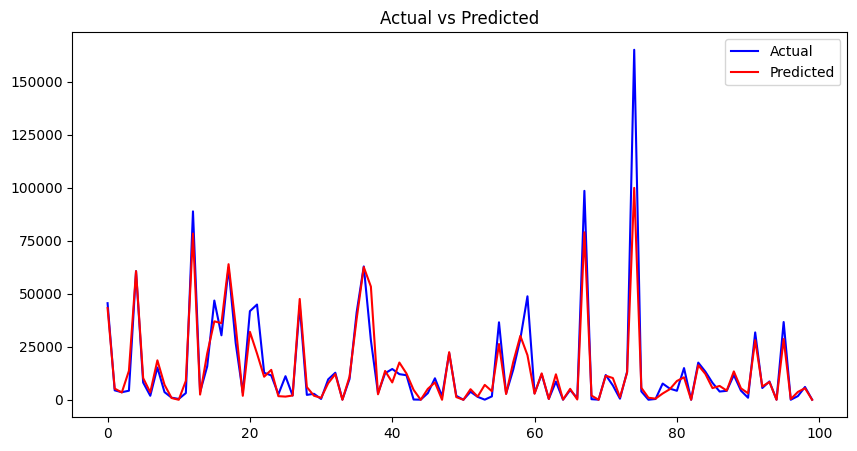

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual", color="blue")
plt.plot(y_pred[:100], label="Predicted", color="red")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
print("\nPrediction Range:")
print("Min:", y_pred.min())
print("Max:", y_pred.max())


Prediction Range:
Min: 0.0
Max: 100000.0


In [ ]:
joblib.dump(model, "xgboost_model_regressor1.pkl")

print("Model trained and saved successfully")

Model trained and saved successfully


In [ ]:
print(X.columns)

Index(['Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
       'Size', 'Year', 'Month', 'Week'],
      dtype='object')
